# XGBoost Regression for Airbnb Price Prediction

## Objective

The objective of this notebook is to develop, optimize, and evaluate an
**Extreme Gradient Boosting (XGBoost) Regressor** to predict Airbnb nightly
prices in Rome.

The model performance will be evaluated using standard regression metrics
and compared against previous baseline models such as Linear Regression and
Random Forest.

The workflow includes:

- Data loading
- Feature selection
- Data preprocessing
- Model training
- Hyperparameter optimization
- Performance evaluation
- Feature importance analysis
- Residual analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import xgboost as xgb

## 1. Load Dataset

The final dataset contains the cleaned and merged Airbnb information.
It combines listing characteristics, availability information, and relevant
features extracted during the preprocessing stage.

The target variable is the Airbnb nightly price.


In [3]:
try:
    df = pd.read_csv("../data/final_dataset.csv")
    print("Dataset successfully loaded.")
    
except FileNotFoundError:
    print(
        "Dataset not found. Please check that "
        "'final_dataset.csv' exists in the data folder."
    )


# %%

df.head()


Dataset successfully loaded.


,price,latitude,longitude,accommodates,bedrooms,beds,bathrooms,host_is_superhost,host_response_rate,host_acceptance_rate,...,distance_to_colosseum,location_cluster,review_count,avg_review_length,avg_sentiment_score,sentiment_label,latest_review_year,latest_review_month,latest_review_day,days_since_latest_review
0,57.0,41.871360,12.482150,1,1.0,1.0,1.5,0,0.0,0.0,...,2.252726,3.0,5.0,51.800000,0.956560,positive,2015.0,5.0,8.0,4077.0
1,110.0,41.895447,12.491181,2,1.0,1.0,1.0,1,100.0,95.0,...,0.588865,4.0,302.0,74.165563,0.849785,positive,2026.0,6.0,7.0,29.0
2,124.0,41.925820,12.469280,6,2.0,3.0,1.0,1,100.0,100.0,...,4.389669,1.0,85.0,84.658824,0.719140,positive,2025.0,8.0,1.0,339.0
3,162.0,41.908230,12.452930,5,2.0,3.0,1.0,0,100.0,99.0,...,3.824847,1.0,195.0,44.953846,0.463973,positive,2026.0,6.0,13.0,23.0
4,150.0,41.908283,12.452617,5,2.0,3.0,1.0,0,100.0,99.0,...,3.850102,1.0,0.0,0.000000,0.000000,no_reviews,-1.0,-1.0,-1.0,9999.0


In [4]:
print(df.shape)

df.info()

(32902, 75)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32902 entries, 0 to 32901
Data columns (total 75 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   price                                              32902 non-null  float64
 1   latitude                                           32902 non-null  float64
 2   longitude                                          32902 non-null  float64
 3   accommodates                                       32902 non-null  int64  
 4   bedrooms                                           32902 non-null  float64
 5   beds                                               32902 non-null  float64
 6   bathrooms                                          32902 non-null  float64
 7   host_is_superhost                                  32902 non-null  int64  
 8   host_response_rate                                 32902 non-null  float64

## 2. Feature Selection and Preparation

Before training the model, we define the explanatory variables and remove
features that should not be used:

- The target variable (`price`) is separated from the predictors.
- The `sentiment_label` is transformed into a dummie varaible in order to be process in the model as a parmeter.

In [5]:
df = pd.get_dummies(df, columns=["sentiment_label"], drop_first=True)

df = df.dropna(subset=["price"])

X = df.drop("price", axis=1)
X = X.astype(float)
y = df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", X.shape[1])



X shape: (32902, 76)
y shape: (32902,)
Number of features: 76


### 2.1 Final Modeling Dataset Validation

Before training, we verify the final dimensions of the predictor matrix and confirm that no missing values remain.

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Number of features:", X.shape[1])

print("Remaining missing values:", df.isnull().sum().sum())

X shape: (32902, 76)
y shape: (32902,)
Number of features: 76
Remaining missing values: 0


## 3. Train-Test Split

The dataset is divided into two subsets:

- Training set: used to learn the model parameters.Using 80% of the data
- Testing set: used to evaluate the model on unseen observations. Using 20% of the data.

We use an 80/20 split and a fixed random state to ensure reproducibility.


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print(
    f"Training observations: {X_train.shape[0]}"
)

print(
    f"Testing observations: {X_test.shape[0]}"
)

Training observations: 26321
Testing observations: 6581


# XGBoost Regressor: Overview and Parameter Guide

## What is XGBoost Regressor?

**XGBoost** (eXtreme Gradient Boosting) is an optimized, highly efficient implementation of the **Gradient Boosted Decision Trees (GBDT)** algorithm designed for speed, scalability, and state-of-the-art predictive performance.

Unlike **Random Forest** (which trains multiple deep decision trees independently in parallel and averages their predictions), **XGBoost builds shallow decision trees sequentially**. 

### How it works:
1. It starts with a baseline prediction (e.g., the average price of all listings).
2. It calculates the prediction errors (residuals) for every data point.
3. It trains a new shallow tree **specifically to predict those residuals** (correcting the mistakes of the previous trees).
4. It updates the overall prediction by adding the new tree's output, scaled by a learning rate.
5. This process repeats sequentially for a specified number of iterations.

---

## Core Parameters Explained

Below is a precise breakdown of the parameters configured in your model:

### 1. `n_estimators=100` (Number of Trees)
* **What it does:** Sets the total number of sequential decision trees to be built during training.
* **The Mechanism:** Because boosting is additive, trees are built one after another. 
* **The Impact:** 
  * If set **too low**, the model will underfit and fail to capture complex relationships.
  * If set **too high**, the model will overfit by capturing random noise in the training set, and training will take significantly longer.

### 2. `learning_rate=0.1` (Shrinkage / Step Size)
* **What it does:** Scalese the contribution of each new tree added to the model (technically called $\eta$).
* **The Mechanism:** When a new tree is trained to correct the errors of previous trees, its predictions are multiplied by the `learning_rate` (e.g., $0.1$ or $10\%$) before being added to the final score. This forces the model to take small, conservative steps toward the optimal solution.
* **The Impact:** 
  * Lower values (like $0.05$ or $0.1$) make the learning process more robust and less prone to overfitting, but require a higher `n_estimators` to fully converge.

### 3. `max_depth=6` (Maximum Tree Depth)
* **What it does:** Restricts the maximum number of splits (levels) allowed for any single decision tree in the ensemble.
* **The Mechanism:** A tree with a `max_depth=6` can split up to 6 consecutive times, creating a maximum of $2^6 = 64$ terminal leaf nodes.
* **The Impact:** 
  * Higher values allow individual trees to capture highly specific multi-variable interactions (raising the risk of overfitting).
  * Values between $3$ and $9$ are typically optimal for tabular data.

### 4. `random_state=42` (Reproducibility Seed)
* **What it does:** Sets a constant seed for the internal pseudo-random number generator.
* **The Mechanism:** XGBoost uses stochastic processes (such as random row/column sampling) to improve generalization. Fixing this seed ensures that these random choices are identical every time the code runs.
* **The Impact:** Guarantees that your performance metrics (MAE, RMSE, $R^2$) remain completely identical across different runs, notebooks, and machines.

### 5. `n_jobs=-1` (Parallel Execution)
* **What it does:** Controls the number of CPU threads allocated to run the training process.
* **The Mechanism:** Setting `n_jobs=-1` instructs your operating system to utilize all available CPU cores in parallel.
* **The Impact:** Drastically reduces training time—especially during hyperparameter tuning (like `RandomizedSearchCV`)—without affecting the mathematical accuracy of the final model.

---

## Parameter Quick-Reference

| Parameter | Default Value | Standard Tuning Range | Primary Objective |
| :--- | :---: | :---: | :--- |
| **`n_estimators`** | `100` | `100 - 1000` | Controls overall model capacity and training duration. |
| **`learning_rate`** | `0.3` | `0.01 - 0.2` | Slows down learning speed to improve generalization. |
| **`max_depth`** | `6` | `3 - 10` | Limits the complexity of individual trees to prevent overfitting. |
| **`random_state`** | `None` | Any Integer | Ensures reproducibility of results across runs. |
| **`n_jobs`** | `None` | `-1` | Accelerates computations using multi-core processing. |

## 5. Baseline XGBoost Model

We first train a baseline XGBoost model using default hyperparameters.

XGBoost is a gradient boosting algorithm that combines multiple weak
learners (decision trees) into a strong predictive model.

Important parameters:

- `n_estimators`: number of trees.
- `learning_rate`: contribution of each tree.
- `max_depth`: maximum depth of each tree.


In [8]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline(steps=[
    ("regressor", xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

print("Baseline XGBoost model trained successfully.")

y_pred = xgb_pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred))

Baseline XGBoost model trained successfully.
MAE: 43.604568248134925
RMSE: 77.17119592218246
R²: 0.592492446601113
MAPE: 0.27863675650735337


## 6. Hyperparameter Optimization

The performance of XGBoost strongly depends on the selection of
hyperparameters.

Randomized Search explores different parameter combinations using
cross-validation and selects the configuration that minimizes the
prediction error.


In [9]:
param_distribution = {

    "regressor__n_estimators":
        [100, 200, 300, 500],

    "regressor__learning_rate":
        [0.01, 0.05, 0.1, 0.2],

    "regressor__max_depth":
        [3, 5, 7, 9],

    "regressor__subsample":
        [0.7, 0.8, 0.9, 1.0],

    "regressor__colsample_bytree":
        [0.7, 0.8, 0.9, 1.0],

    "regressor__reg_alpha":
        [0, 0.1, 1, 10],

    "regressor__reg_lambda":
        [1, 2, 5, 10]
}


# %%
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distribution,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


print(
    "Starting hyperparameter optimization..."
)


random_search.fit(
    X_train,
    y_train
)


best_model = random_search.best_estimator_


print(
    "Best parameters:"
)

print(
    random_search.best_params_
)



Starting hyperparameter optimization...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters:
{'regressor__subsample': 0.9, 'regressor__reg_lambda': 2, 'regressor__reg_alpha': 1, 'regressor__n_estimators': 200, 'regressor__max_depth': 7, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 0.8}


## 7. Model Evaluation

The optimized model is evaluated using:

**MAE (Mean Absolute Error)**

Average absolute difference between predicted and real prices.


**RMSE (Root Mean Squared Error)**

Penalizes larger prediction errors more strongly.


**R² Score**

Measures the proportion of variance explained by the model.



In [10]:
y_pred = best_model.predict(
    X_test
)

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
)


mae = mean_absolute_error(
    y_test,
    y_pred
)


rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


r2 = r2_score(
    y_test,
    y_pred
)


print("XGBoost Performance")
print("-------------------")

print(
    f"MAE: {mae:.2f} €"
)

print(
    f"RMSE: {rmse:.2f} €"
)

print(
    f"R² Score: {r2:.4f}"
)
print(
    f"MAPE: {mape:.2%}"
)

XGBoost Performance
-------------------
MAE: 43.14 €
RMSE: 76.17 €
R² Score: 0.6030
MAPE: 27.53%


In [11]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        np.repeat(y_train.mean(), len(y_test))
    )
)

print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline RMSE: 120.94


## 8. Feature Importance Analysis

XGBoost provides feature importance values that help identify which
variables contribute the most to price prediction.

This analysis is useful for interpreting the model and understanding
Airbnb pricing drivers in Rome.



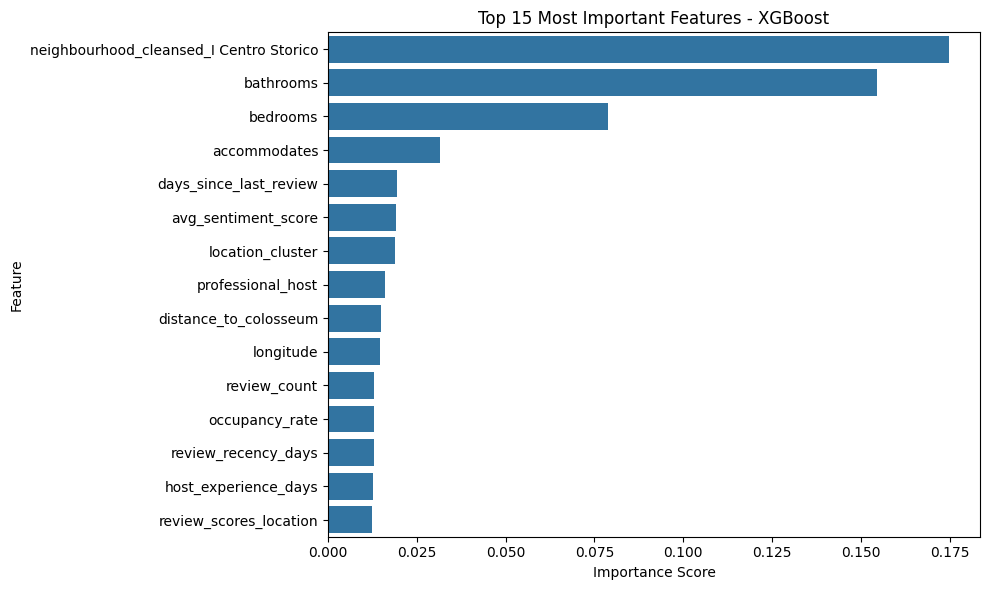

In [12]:
all_features = X.columns.tolist()

importance_values = best_model.named_steps["regressor"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(15)

# %%
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Most Important Features - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

On point that stands out is the`neighbourhood_cleansed_l Centro Storico`, therefore we made a correlation matrix to find out if there was a correlation between the geographycal features and the price.
The correlation matrix shows that the location variables are strongly interrelated. The fact that the “Centro Storico” dummy variable has the highest linear correlation with price (0.34) compared to distance from the Colosseum (−0.21) explains why tree-based models assign it a dominant weight. This is not a model error; rather, it reflects the fact that the “Historic District” label is the clearest and most powerful geographic driver for explaining prices in Rome.

Translated with DeepL.com (free version)

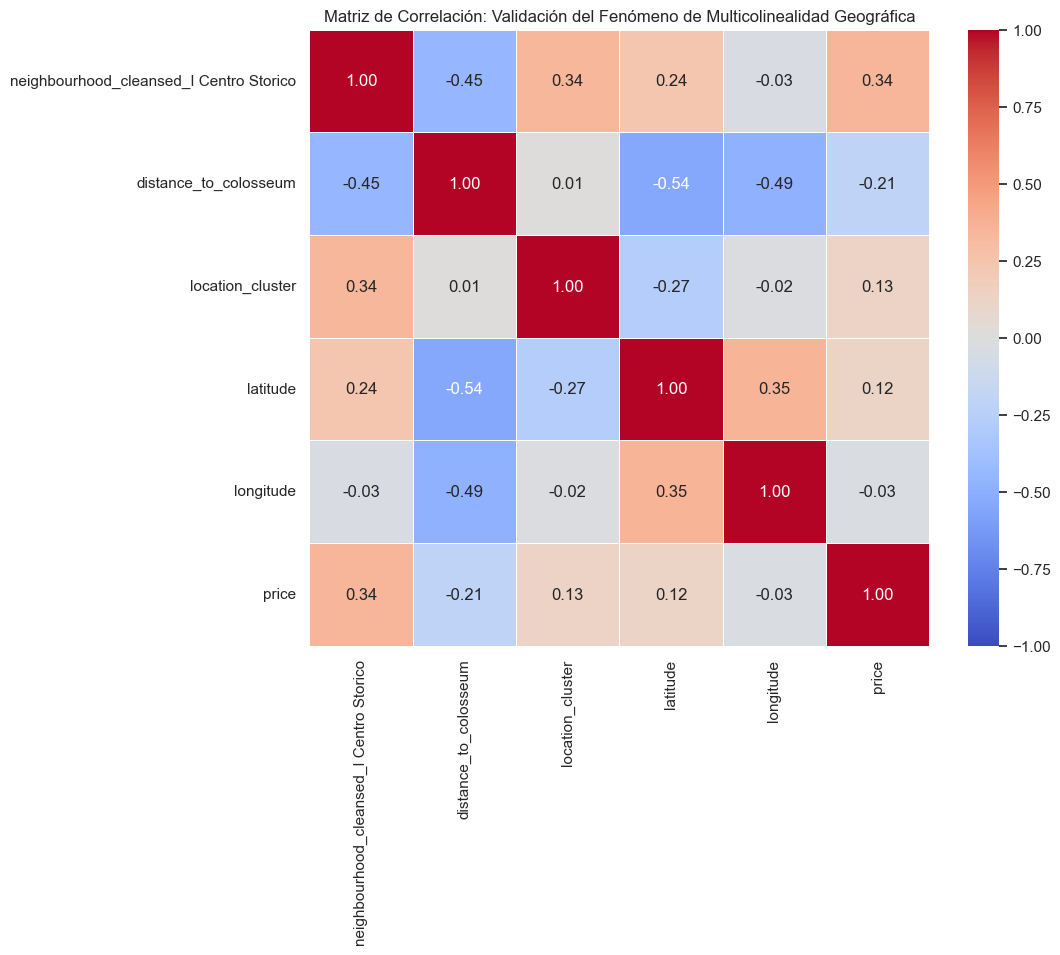

In [17]:

# 1. Seleccionamos las variables geográficas clave mencionadas
geo_vars = [
    'neighbourhood_cleansed_I Centro Storico', 
    'distance_to_colosseum', 
    'location_cluster', 
    'latitude', 
    'longitude', 
    'price'
]

# 2. Calculamos la matriz de correlación de Pearson
geo_corr = df[geo_vars].corr()

# 3. Graficamos el Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(geo_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación: Validación del Fenómeno de Multicolinealidad Geográfica')
plt.show()

## 9. Residual Analysis

Residual analysis evaluates whether the model systematically
overestimates or underestimates prices.

Ideally, residuals should be randomly distributed around zero.



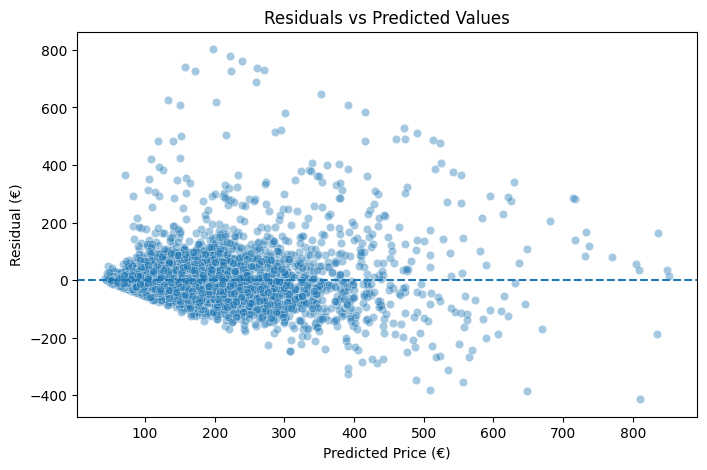

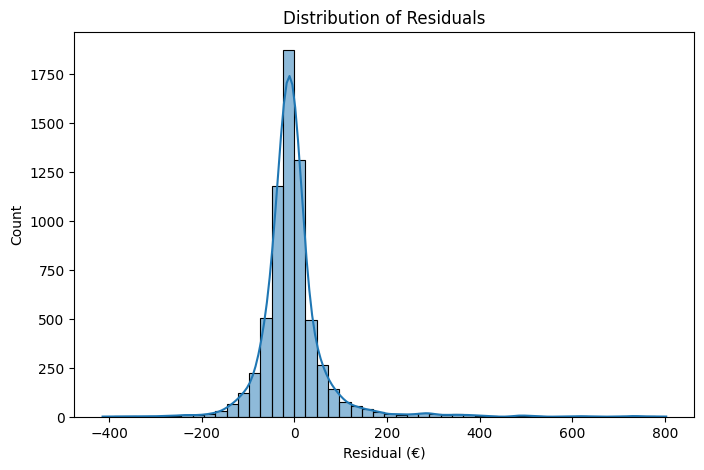

In [13]:
residuals = y_test - y_pred


plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Residuals vs Predicted Values"
)

plt.xlabel(
    "Predicted Price (€)"
)

plt.ylabel(
    "Residual (€)"
)

plt.show()


# %%
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title(
    "Distribution of Residuals"
)

plt.xlabel(
    "Residual (€)"
)

plt.show()

## GENERAL COMPARATION BETWEEN DIFFERENT SCENARIOS OF PARAMTERES


## Experimenting with Hyperparameter Combinations

To understand how changing our "detective team" parameters impacts performance, 
we will test 5 distinct configurations. This experiment helps us observe the trade-offs 
between tree depth, learning speed, and ensemble size.


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import xgboost as xgb

# 1. Define the different configurations we want to experiment with
scenarios = [
    {
        "name": "Underfitted (Few trees, very shallow)",
        "n_estimators": 10,
        "learning_rate": 0.1,
        "max_depth": 3
    },
    {
        "name": "Fast Learner (High learning rate, deep trees)",
        "n_estimators": 50,
        "learning_rate": 0.3,
        "max_depth": 8
    },
    {
        "name": "Standard Baseline (Your current configuration)",
        "n_estimators": 100,
        "learning_rate": 0.1,
        "max_depth": 6
    },
    {
        "name": "Conservative & Deep (Slow learning, deeper trees)",
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 8
    },
    {
        "name": "Overfitted / Complex (Many trees, very deep)",
        "n_estimators": 500,
        "learning_rate": 0.2,
        "max_depth": 10
    }
]

# 2. Loop through scenarios, train, and evaluate
results_list = []

print("Running parameter sweep...")
for run in scenarios:
    print(f"Training: {run['name']}...")

    model = xgb.XGBRegressor(
        n_estimators=run["n_estimators"],
        learning_rate=run["learning_rate"],
        max_depth=run["max_depth"],
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(steps=[
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results_list.append({
        "Scenario Name": run["name"],
        "n_estimators": run["n_estimators"],
        "learning_rate": run["learning_rate"],
        "max_depth": run["max_depth"],
        "MAE (€)": round(mae, 2),
        "RMSE (€)": round(rmse, 2),
        "R² Score": round(r2, 4)
    })

# 3. Convert results to a pandas DataFrame for structured visualization
df_results = pd.DataFrame(results_list)

# Highlight the best scores (lowest MAE/RMSE and highest R²) for quick comparison
df_results.style.highlight_min(subset=["MAE (€)", "RMSE (€)"], color="lightgreen") \
                  .highlight_max(subset=["R² Score"], color="lightgreen")

Running parameter sweep...
Training: Underfitted (Few trees, very shallow)...
Training: Fast Learner (High learning rate, deep trees)...
Training: Standard Baseline (Your current configuration)...
Training: Conservative & Deep (Slow learning, deeper trees)...
Training: Overfitted / Complex (Many trees, very deep)...


,Scenario Name,n_estimators,learning_rate,max_depth,MAE (€),RMSE (€),R² Score
0,"Underfitted (Few trees, very shallow)",10,0.100000,3,59.700000,97.560000,0.348700
1,"Fast Learner (High learning rate, deep trees)",50,0.300000,8,46.090000,79.480000,0.567800
2,Standard Baseline (Your current configuration),100,0.100000,6,43.600000,77.170000,0.592500
3,"Conservative & Deep (Slow learning, deeper trees)",200,0.050000,8,43.030000,75.530000,0.609600
4,"Overfitted / Complex (Many trees, very deep)",500,0.200000,10,45.500000,78.990000,0.573100



## Visualizing Hyperparameter Performance (The 5 Moments)

 We will plot the three evaluation metrics side-by-side to visually identify 
 where underfitting ends, where the optimal configuration lies, and where 
 overfitting begins.



/var/folders/zr/mk8gxw5572ld75z4fsbmmc6c0000gn/T/ipykernel_6862/610202090.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/zr/mk8gxw5572ld75z4fsbmmc6c0000gn/T/ipykernel_6862/610202090.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/zr/mk8gxw5572ld75z4fsbmmc6c0000gn/T/ipykernel_6862/610202090.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


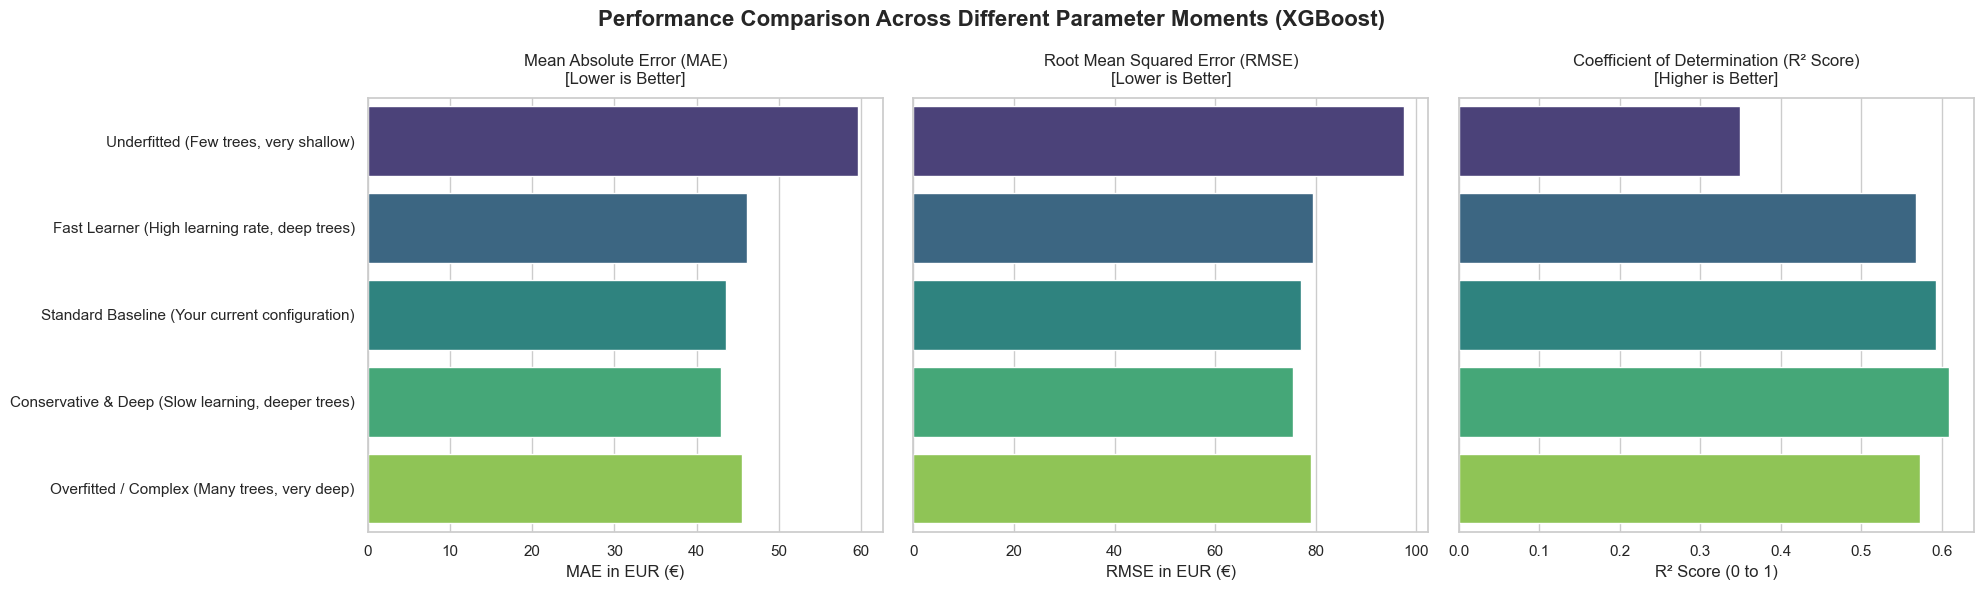

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual de seaborn
sns.set_theme(style="whitegrid")

# Crear una figura con 3 subgráficos en una sola fila
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.suptitle('Performance Comparison Across Different Parameter Moments (XGBoost)', fontsize=16, fontweight='bold')

# Paleta de colores para diferenciar los momentos
palette = sns.color_palette("viridis", len(df_results))

# 1. Gráfico para MAE (Menor es mejor)
sns.barplot(
    x='MAE (€)', 
    y='Scenario Name', 
    data=df_results, 
    ax=axes[0], 
    palette=palette
)
axes[0].set_title('Mean Absolute Error (MAE)\n[Lower is Better]', fontsize=12, pad=10)
axes[0].set_xlabel('MAE in EUR (€)')
axes[0].set_ylabel('')  # Ocultar etiqueta del eje Y en los siguientes para limpieza

# 2. Gráfico para RMSE (Menor es mejor)
sns.barplot(
    x='RMSE (€)', 
    y='Scenario Name', 
    data=df_results, 
    ax=axes[1], 
    palette=palette
)
axes[1].set_title('Root Mean Squared Error (RMSE)\n[Lower is Better]', fontsize=12, pad=10)
axes[1].set_xlabel('RMSE in EUR (€)')
axes[1].set_ylabel('')
axes[1].set_yticklabels([])  # Ocultar nombres de escenarios en el centro para evitar repetición

# 3. Gráfico para R² Score (Mayor es mejor)
sns.barplot(
    x='R² Score', 
    y='Scenario Name', 
    data=df_results, 
    ax=axes[2], 
    palette=palette
)
axes[2].set_title('Coefficient of Determination (R² Score)\n[Higher is Better]', fontsize=12, pad=10)
axes[2].set_xlabel('R² Score (0 to 1)')
axes[2].set_ylabel('')
axes[2].set_yticklabels([])  # Ocultar nombres de escenarios a la derecha

# Ajustar el diseño para que no se encabalguen los textos
plt.tight_layout()
plt.show()